In [2]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#%cd "/content/drive/MyDrive/GCI_FinalAssignment/Final Assignment"
%cd "/content/drive/MyDrive/GCI_FinalAssignment/Final Assignment"

/content/drive/MyDrive/GCI_FinalAssignment/Final Assignment


In [4]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/GCI_FinalAssignment/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/GCI_FinalAssignment/Final Assignment/telecom/Record.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [7]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,O,0.0,I,U,U,U,U,U,Y,434.0


In [8]:
df.shape

(100000, 100)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

In [10]:
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,50.438
1,49.562


In [11]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].head(20)

,0
numbcars,49.366
dwllsize,38.308
HHstatin,37.923
ownrent,33.706
dwlltype,31.909
lor,30.190
income,25.436
adults,23.019
infobase,22.079
hnd_webcap,10.189


In [12]:
df[['rev_Mean','mou_Mean','months','eqpdays']].describe()

,rev_Mean,mou_Mean,months,eqpdays
count,99643.000000,99643.000000,100000.000000,99999.000000
mean,58.719985,513.559937,18.833990,391.932309
std,46.291677,525.168140,9.655794,256.482193
min,-6.167500,0.000000,6.000000,-5.000000
25%,33.260000,150.750000,11.000000,212.000000
50%,48.195000,355.500000,16.000000,342.000000
75%,70.750000,703.000000,24.000000,530.000000
max,3843.262500,12206.750000,61.000000,1823.000000


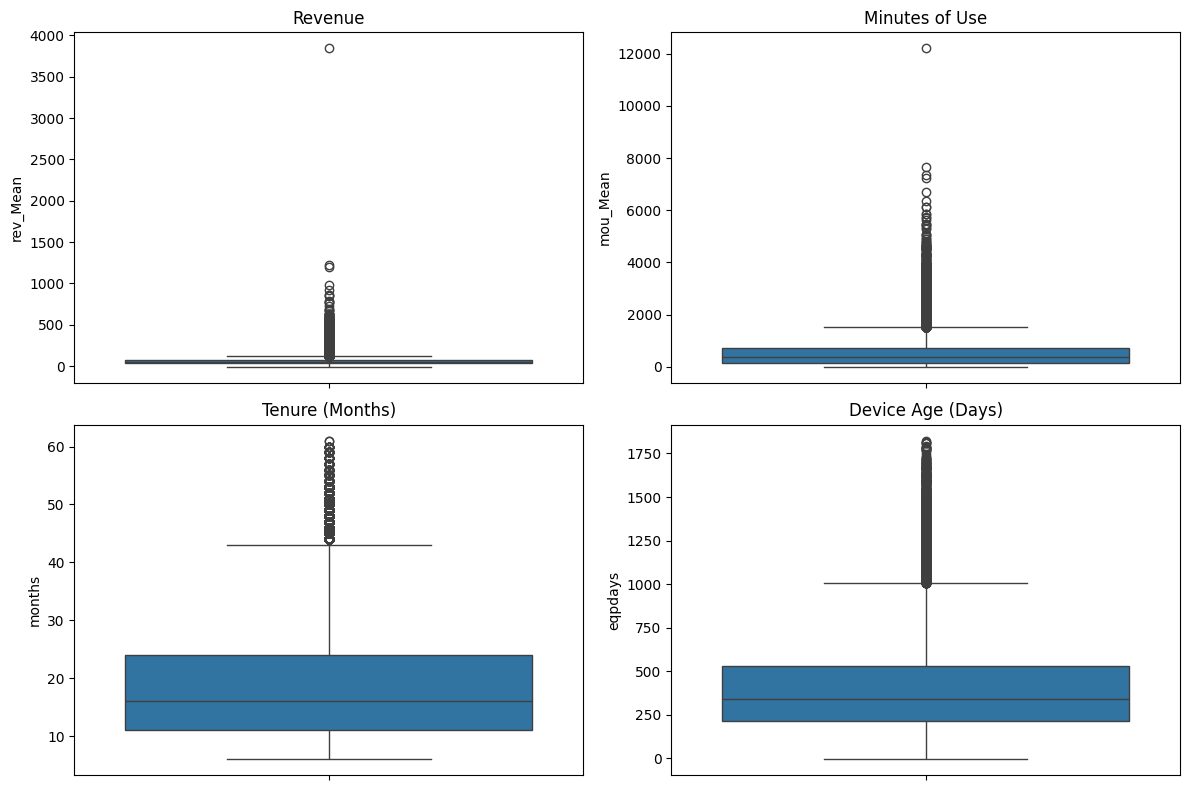

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(y=df['rev_Mean'], ax=axes[0,0])
axes[0,0].set_title('Revenue')

sns.boxplot(y=df['mou_Mean'], ax=axes[0,1])
axes[0,1].set_title('Minutes of Use')

sns.boxplot(y=df['months'], ax=axes[1,0])
axes[1,0].set_title('Tenure (Months)')

sns.boxplot(y=df['eqpdays'], ax=axes[1,1])
axes[1,1].set_title('Device Age (Days)')

plt.tight_layout()
plt.show()

In [14]:
df.groupby('churn')[['rev_Mean','mou_Mean','months','eqpdays']].mean()

,rev_Mean,mou_Mean,months,eqpdays
churn,,,,
0,59.218692,543.206895,18.633074,363.280925
1,58.211074,483.306417,19.038457,421.089524


In [15]:
df.groupby('churn')[[
    'change_mou',
    'change_rev',
    'drop_blk_Mean',
    'custcare_Mean',
    'eqpdays'
]].mean()

,change_mou,change_rev,drop_blk_Mean,custcare_Mean,eqpdays
churn,,,,,
0,-5.344265,-1.410195,10.286563,1.982599,363.280925
1,-22.759003,-0.621263,9.797752,1.595688,421.089524


In [16]:
corr_cols = [
    'churn',
    'change_mou',
    'change_rev',
    'eqpdays',
    'rev_Mean',
    'mou_Mean',
    'months'
]

df[corr_cols].corr()['churn'].sort_values(ascending=False)

,churn
churn,1.000000
eqpdays,0.112691
months,0.020991
change_rev,0.007832
rev_Mean,-0.010883
change_mou,-0.031536
mou_Mean,-0.057027


In [17]:
corr_with_churn = (
    df.select_dtypes(include=['int64','float64'])
      .corr()['churn']
      .sort_values(ascending=False)
)

corr_with_churn.head(30)

,churn
churn,1.000000
eqpdays,0.112691
uniqsubs,0.039882
vceovr_Mean,0.024240
ovrrev_Mean,0.023736
months,0.020991
ovrmou_Mean,0.019720
actvsubs,0.019686
roam_Mean,0.009324
change_rev,0.007832


In [18]:
corr_with_churn.tail(30)

,churn
mouowylisv_Mean,-0.034914
mouiwylisv_Mean,-0.035021
cc_mou_Mean,-0.035248
unan_vce_Mean,-0.035560
custcare_Mean,-0.036393
ccrndmou_Mean,-0.037890
avg6qty,-0.038826
phones,-0.039457
iwylis_vce_Mean,-0.040853
recv_vce_Mean,-0.041779


In [19]:
df[['eqpdays', 'mou_Mean', 'rev_Mean', 'change_mou']].corr()

,eqpdays,mou_Mean,rev_Mean,change_mou
eqpdays,1.000000,-0.315322,-0.213402,-0.007486
mou_Mean,-0.315322,1.000000,0.706029,-0.008211
rev_Mean,-0.213402,0.706029,1.000000,0.075835
change_mou,-0.007486,-0.008211,0.075835,1.000000


In [19]:
df[['eqpdays','rev_Mean']].corr()

,eqpdays,rev_Mean
eqpdays,1.000000,-0.213402
rev_Mean,-0.213402,1.000000


In [20]:
df['device_age_group'] = pd.cut(
    df['eqpdays'],
    bins=[0,180,365,730,2000],
    labels=['<6m','6-12m','1-2y','2y+']
)

df.groupby('device_age_group')[['rev_Mean','mou_Mean','churn']].mean()

/tmp/ipykernel_3745/1072918249.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('device_age_group')[['rev_Mean','mou_Mean','churn']].mean()


,rev_Mean,mou_Mean,churn
device_age_group,,,
<6m,78.684823,793.777736,0.418094
6-12m,59.305923,560.659999,0.469716
1-2y,52.290247,399.897175,0.538386
2y+,43.146476,236.299163,0.578947


In [21]:
pd.qcut(df['change_mou'], q=4).value_counts().sort_index()

,count
change_mou,
"(-3875.001, -87.0]",24805
"(-87.0, -6.25]",24863
"(-6.25, 63.0]",24702
"(63.0, 31219.25]",24739


In [22]:
df['usage_change_group'] = pd.qcut(
    df['change_mou'],
    q=4,
    duplicates='drop'
)

df.groupby('usage_change_group')[['rev_Mean','churn']].mean()

/tmp/ipykernel_3745/1174647170.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_change_group')[['rev_Mean','churn']].mean()


,rev_Mean,churn
usage_change_group,,
"(-3875.001, -87.0]",74.074152,0.533723
"(-87.0, -6.25]",45.873666,0.493464
"(-6.25, 63.0]",42.474095,0.480852
"(63.0, 31219.25]",72.717577,0.464772


In [23]:
df[['eqpdays', 'months', 'churn']].corr()

,eqpdays,months,churn
eqpdays,1.000000,0.483320,0.112691
months,0.483320,1.000000,0.020991
churn,0.112691,0.020991,1.000000


In [24]:
pd.qcut(df['months'], q=4).value_counts().sort_index()

,count
months,
"(5.999, 11.0]",26410
"(11.0, 16.0]",23671
"(16.0, 24.0]",25230
"(24.0, 61.0]",24689


In [25]:
df['tenure_group'] = pd.qcut(
    df['months'],
    q=4,
    duplicates='drop'
)

df.groupby('tenure_group')[['rev_Mean','mou_Mean','churn']].mean()

/tmp/ipykernel_3745/2990048122.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')[['rev_Mean','mou_Mean','churn']].mean()


,rev_Mean,mou_Mean,churn
tenure_group,,,
"(5.999, 11.0]",59.998886,589.248137,0.433321
"(11.0, 16.0]",59.134571,535.801247,0.554434
"(16.0, 24.0]",57.993570,473.311817,0.507531
"(24.0, 61.0]",57.684881,451.693802,0.493702


In [26]:
df[['hnd_price','rev_Mean','mou_Mean','churn']].corr()

,hnd_price,rev_Mean,mou_Mean,churn
hnd_price,1.000000,0.167376,0.231482,-0.103184
rev_Mean,0.167376,1.000000,0.706029,-0.010883
mou_Mean,0.231482,0.706029,1.000000,-0.057027
churn,-0.103184,-0.010883,-0.057027,1.000000


In [27]:
df.groupby('new_cell')[['eqpdays','rev_Mean','mou_Mean','churn']].mean()

,eqpdays,rev_Mean,mou_Mean,churn
new_cell,,,,
N,418.719188,63.245594,566.322542,0.496627
U,378.209735,57.400682,497.216113,0.496951
Y,420.374437,60.053726,532.439547,0.490285


In [28]:
new_device = df[df['device_age_group'] == '<6m']

new_device.groupby('churn')[[
    'drop_vce_Mean',
    'drop_dat_Mean',
    'blck_vce_Mean',
    'drop_blk_Mean',
    'custcare_Mean',
    'ovrrev_Mean',
    'change_mou',
    'change_rev',
    'rev_Mean',
    'mou_Mean'
]].mean()

,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,drop_blk_Mean,custcare_Mean,ovrrev_Mean,change_mou,change_rev,rev_Mean,mou_Mean
churn,,,,,,,,,,
0,9.512207,0.081346,6.190607,15.885945,3.315134,19.835979,8.819969,-2.331134,76.770914,791.676107
1,9.979652,0.076474,6.894991,16.999802,3.148580,24.536657,-6.496042,-0.324554,81.349939,796.704250


In [29]:
df.groupby('churn')[[
    'ovrrev_Mean',
    'ovrmou_Mean',
    'vceovr_Mean',
    'datovr_Mean'
]].mean()

,ovrrev_Mean,ovrmou_Mean,vceovr_Mean,datovr_Mean
churn,,,,
0,12.842879,39.172904,12.573835,0.265309
1,14.290904,43.010449,14.031045,0.257244


In [30]:
candidate_features = [
    'eqpdays',
    'hnd_price',
    'change_mou',
    'ovrrev_Mean',
    'mou_Mean',
    'rev_Mean',
    'months'
]

for col in candidate_features:
    print(f"\n{col}")
    print(df.groupby('churn')[col].describe()[['mean','50%']])


eqpdays
             mean    50%
churn                   
0      363.280925  310.0
1      421.089524  366.0

hnd_price
             mean        50%
churn                       
0      108.129344  129.98999
1       95.539523   99.98999

change_mou
            mean   50%
churn                 
0      -5.344265  -3.0
1     -22.759003 -10.0

ovrrev_Mean
            mean  50%
churn                
0      12.842879  0.8
1      14.290904  1.2

mou_Mean
             mean     50%
churn                    
0      543.206895  380.50
1      483.306417  329.75

rev_Mean
            mean       50%
churn                     
0      59.218692  48.87625
1      58.211074  47.49000

months
            mean   50%
churn                 
0      18.633074  16.0
1      19.038457  17.0


In [31]:
df.groupby('churn')[[
    'totmrc_Mean',
    'ovrmou_Mean',
    'ovrrev_Mean',
    'vceovr_Mean',
    'datovr_Mean',
    'roam_Mean',
    'da_Mean'
]].agg(['mean','median'])

totmrc_Mean          ovrmou_Mean        ovrrev_Mean        vceovr_Mean  \
             mean   median        mean median        mean median        mean   
churn                                                                          
0       47.782378  44.9900   39.172904   2.25   12.842879    0.8   12.573835   
1       44.543091  43.4175   43.010449   3.50   14.290904    1.2   14.031045   

              datovr_Mean        roam_Mean          da_Mean          
       median        mean median      mean median      mean  median  
churn                                                                
0      0.4375    0.265309    0.0  1.150619    0.0  0.918039  0.2475  
1      0.9625    0.257244    0.0  1.424969    0.0  0.859019  0.2475

In [32]:
df[['totmrc_Mean',
    'ovrmou_Mean',
    'ovrrev_Mean',
    'vceovr_Mean',
    'roam_Mean',
    'churn']].corr()['churn']

,churn
totmrc_Mean,-0.068558
ovrmou_Mean,0.019720
ovrrev_Mean,0.023736
vceovr_Mean,0.024240
roam_Mean,0.009324
churn,1.000000


In [33]:
top_customer = df.loc[df['rev_Mean'].idxmax()]

top_customer[[
    'Customer_ID',
    'rev_Mean',
    'mou_Mean',
    'months',
    'eqpdays',
    'hnd_price',
    'ovrrev_Mean',
    'ovrmou_Mean',
    'change_mou',
    'change_rev',
    'churn'
]]

,39170
Customer_ID,1039171
rev_Mean,3843.2625
mou_Mean,12206.75
months,16
eqpdays,54.0
hnd_price,149.98999
ovrrev_Mean,28.8075
ovrmou_Mean,82.25
change_mou,31219.25
change_rev,9963.6575


In [34]:
top1 = df[df['rev_Mean'] >= df['rev_Mean'].quantile(0.99)]

top1[['rev_Mean',
      'mou_Mean',
      'months',
      'eqpdays',
      'hnd_price',
      'ovrrev_Mean',
      'churn']].describe()

,rev_Mean,mou_Mean,months,eqpdays,hnd_price,ovrrev_Mean,churn
count,997.000000,997.000000,997.000000,997.000000,977.000000,997.000000,997.000000
mean,319.727357,2308.338683,19.492477,243.487462,133.551915,185.137631,0.515547
std,156.643051,1074.946115,10.489390,188.504970,62.990733,115.829828,0.500009
min,227.902500,43.000000,6.000000,-4.000000,9.989998,0.000000,0.000000
25%,247.730000,1608.250000,12.000000,88.000000,99.989990,118.562500,0.000000
50%,279.267500,2126.750000,17.000000,209.000000,129.989990,178.312500,1.000000
75%,338.242500,2803.000000,24.000000,350.000000,179.989990,232.500000,1.000000
max,3843.262500,12206.750000,56.000000,1151.000000,499.989990,1102.400000,1.000000


In [35]:
top1 = df[df['rev_Mean'] >= df['rev_Mean'].quantile(0.99)]

top1.groupby('churn')[[
    'rev_Mean',
    'mou_Mean',
    'ovrrev_Mean',
    'eqpdays',
    'hnd_price',
    'change_mou'
]].mean()

,rev_Mean,mou_Mean,ovrrev_Mean,eqpdays,hnd_price,change_mou
churn,,,,,,
0,320.269218,2405.431332,183.873216,229.565217,136.749052,0.556246
1,319.218176,2217.101816,186.325788,256.570039,130.600227,-2.496055


/tmp/ipykernel_3745/3564025351.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  device_summary = df.groupby('device_age_group')[['rev_Mean','mou_Mean','churn']].mean()


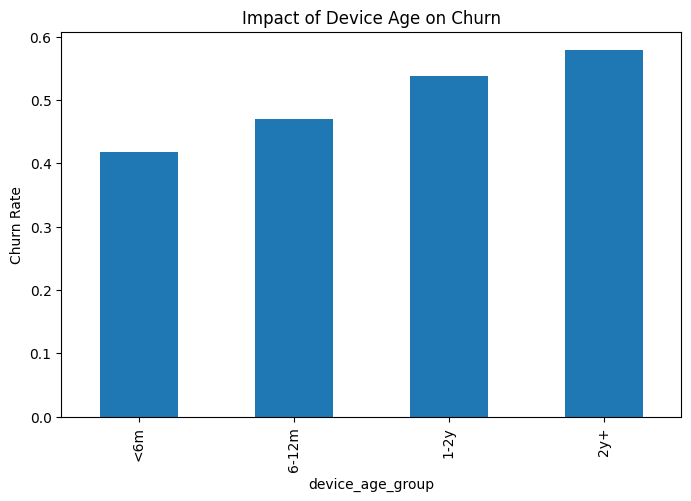

In [36]:
import matplotlib.pyplot as plt

device_summary = df.groupby('device_age_group')[['rev_Mean','mou_Mean','churn']].mean()

fig, ax1 = plt.subplots(figsize=(8,5))

device_summary['churn'].plot(kind='bar', ax=ax1)
plt.title('Impact of Device Age on Churn')
plt.ylabel('Churn Rate')

plt.show()

In [37]:
df.select_dtypes(include=['object']).columns.tolist()

['new_cell',
 'crclscod',
 'asl_flag',
 'prizm_social_one',
 'area',
 'dualband',
 'refurb_new',
 'hnd_webcap',
 'ownrent',
 'dwlltype',
 'marital',
 'infobase',
 'HHstatin',
 'dwllsize',
 'ethnic',
 'kid0_2',
 'kid3_5',
 'kid6_10',
 'kid11_15',
 'kid16_17',
 'creditcd']

In [38]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()}")

new_cell: 3
crclscod: 54
asl_flag: 2
prizm_social_one: 5
area: 19
dualband: 4
refurb_new: 2
hnd_webcap: 3
ownrent: 2
dwlltype: 2
marital: 5
infobase: 2
HHstatin: 6
dwllsize: 15
ethnic: 17
kid0_2: 2
kid3_5: 2
kid6_10: 2
kid11_15: 2
kid16_17: 2
creditcd: 2


In [39]:
df['crclscod'].value_counts().head(20)

,count
crclscod,
AA,36509
A,16996
BA,12667
CA,8334
EA,6419
B,4110
DA,3669
ZA,3493
C,1456


In [40]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['churn', 'Customer_ID'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(80000, 101) (20000, 101)


In [41]:
[col for col in df.columns if 'group' in col.lower()]

['device_age_group', 'usage_change_group', 'tenure_group']

In [42]:
X = df.drop(columns=[
    'Customer_ID',
    'churn',
    'device_age_group',
    'usage_change_group',
    'tenure_group'
])

y = df['churn']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (80000, 98)
Test shape : (20000, 98)


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Separate numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Numerical preprocessing
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 77
Categorical Columns: 21


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression Pipeline
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

In [48]:
# Extract trained RF
rf = rf_model.named_steps['classifier']

# Get transformed feature names
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

importance_df.head(20)

,feature,importance
76,num__eqpdays,0.030626
9,num__change_mou,0.023771
48,num__months,0.023477
1,num__mou_Mean,0.019529
54,num__adjrev,0.019527
10,num__change_rev,0.019055
53,num__totrev,0.018945
57,num__avgrev,0.018814
59,num__avgqty,0.018812
58,num__avgmou,0.018253


In [46]:
from sklearn.model_selection import cross_validate

def evaluate_model(model, X_train, y_train):

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1',
            'roc_auc'
        ],
        n_jobs=-1
    )

    print("Accuracy :", round(scores['test_accuracy'].mean(), 4))
    print("Precision:", round(scores['test_precision'].mean(), 4))
    print("Recall   :", round(scores['test_recall'].mean(), 4))
    print("F1 Score :", round(scores['test_f1'].mean(), 4))
    print("ROC AUC  :", round(scores['test_roc_auc'].mean(), 4))

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ))
])

evaluate_model(dt_model, X_train, y_train)

Accuracy : 0.5998
Precision: 0.592
Recall   : 0.6228
F1 Score : 0.6058
ROC AUC  : 0.6381


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_cv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_model(rf_cv_model, X_train, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Accuracy : 0.623
Precision: 0.6195
Recall   : 0.6205
F1 Score : 0.62
ROC AUC  : 0.6729


In [52]:
import xgboost
print(xgboost.__version__)

3.2.0


In [53]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

evaluate_model(xgb_model, X_train, y_train)

Accuracy : 0.6366
Precision: 0.6306
Recall   : 0.6443
F1 Score : 0.6374
ROC AUC  : 0.6926


In [54]:
# Fit on full training set
xgb_model.fit(X_train, y_train)

xgb = xgb_model.named_steps['classifier']

feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

importance_df.head(20)

,feature,importance
163,cat__refurb_new_N,0.023058
76,num__eqpdays,0.020068
134,cat__asl_flag_Y,0.019908
48,num__months,0.016999
66,num__hnd_price,0.011951
216,cat__ethnic_Z,0.011760
210,cat__ethnic_O,0.011478
101,cat__crclscod_EA,0.011319
133,cat__asl_flag_N,0.011069
1,num__mou_Mean,0.009961


In [55]:
df.groupby('refurb_new')[[
    'churn',
    'eqpdays',
    'hnd_price',
    'mou_Mean',
    'rev_Mean'
]].mean()

,churn,eqpdays,hnd_price,mou_Mean,rev_Mean
refurb_new,,,,,
N,0.489105,409.488159,109.071914,498.828102,57.916047
R,0.534361,287.624531,59.408103,601.178632,63.498242


In [48]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.7 MB/s eta 0:00:00


In [49]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

cat_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        random_state=42,
        verbose=0
    ))
])

evaluate_model(cat_model, X_train, y_train)

Accuracy : 0.6384
Precision: 0.6317
Recall   : 0.6483
F1 Score : 0.6399
ROC AUC  : 0.6928


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

ada_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

evaluate_model(ada_model, X_train, y_train)

In [ ]:
import os

save_path = "/content/drive/MyDrive/GCI_FinalAssignment/Final Assignment"

os.makedirs(save_path, exist_ok=True)

print("Models will be saved to:", save_path)

In [ ]:
import joblib

joblib.dump(dt_model,  f"{save_path}/decision_tree.pkl")
joblib.dump(rf_model,  f"{save_path}/random_forest.pkl")
joblib.dump(ada_model, f"{save_path}/adaboost.pkl")
joblib.dump(xgb_model, f"{save_path}/xgboost.pkl")
joblib.dump(cat_model, f"{save_path}/catboost.pkl")

print("All models saved successfully!")

In [50]:
import pandas as pd
from catboost import Pool

cat_clf = cat_model.named_steps['classifier']
preprocessor = cat_model.named_steps['preprocessor']

# Re-fit the cat_model to ensure the classifier is in a trained state in the current session
# This also ensures the preprocessor is fitted and transforms data consistently
cat_model.fit(X_train, y_train)

# Get the transformed X_train data which the CatBoostClassifier was trained on
X_train_transformed = preprocessor.transform(X_train)

# Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create a CatBoost Pool from the transformed (numerical) data
# No need to specify cat_features as they are already one-hot encoded and numerical
catboost_pool = Pool(data=X_train_transformed, label=y_train)

# Calculate feature importances using the created CatBoost Pool
cat_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': cat_clf.get_feature_importance(data=catboost_pool)
})

cat_importance_df = cat_importance_df.sort_values(
    'importance',
    ascending=False
)

cat_importance_df.head(20)

,feature,importance
48,num__months,10.996072
76,num__eqpdays,9.048197
9,num__change_mou,7.257531
1,num__mou_Mean,6.493265
2,num__totmrc_Mean,5.202114
66,num__hnd_price,3.360129
10,num__change_rev,3.079838
49,num__uniqsubs,1.984856
71,num__lor,1.824522
59,num__avgqty,1.819818


In [67]:
y_prob = cat_model.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    'actual_churn': y_test,
    'risk_score': y_prob
})

risk_df['risk_decile'] = pd.qcut(
    risk_df['risk_score'],
    10,
    labels=False
)

risk_df.groupby('risk_decile')['actual_churn'].agg(
    ['count','mean']
).sort_index()

,count,mean
risk_decile,,
0,2000,0.1950
1,2000,0.3205
2,2000,0.3605
3,2000,0.4370
4,2000,0.4720
5,2000,0.5240
6,2000,0.5565
7,2000,0.6155
8,2000,0.6965


In [68]:
overall_churn = y_test.mean()

print("Overall Churn Rate:", overall_churn)
print("Top Decile Churn Rate:", risk_df[risk_df['risk_decile']==9]['actual_churn'].mean())

Overall Churn Rate: 0.4956
Top Decile Churn Rate: 0.7785


<Axes: xlabel='risk_decile'>

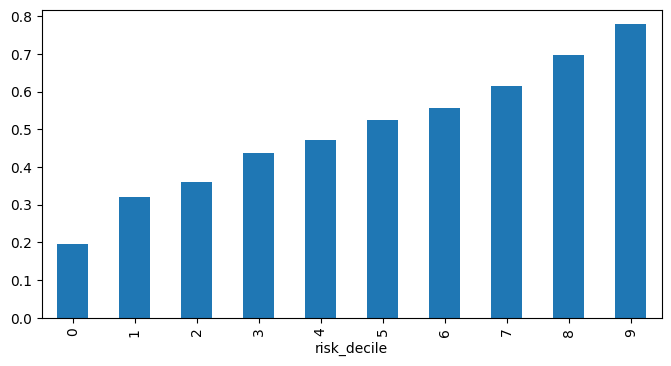

In [69]:
risk_df.groupby('risk_decile')['actual_churn'].mean().plot(
    kind='bar',
    figsize=(8,4)
)

In [70]:
!pip install shap -q

import shap
import matplotlib.pyplot as plt

print(shap.__version__)

0.52.0


In [71]:
import shap

cat_clf = cat_model.named_steps['classifier']

explainer = shap.TreeExplainer(cat_clf)

print("SHAP Explainer Created Successfully")

SHAP Explainer Created Successfully


In [85]:
# Use only 1000 rows for SHAP analysis
X_sample = X_train.sample(1000, random_state=42)

# Transform using the fitted preprocessor
X_sample_transformed = cat_model.named_steps[
    'preprocessor'
].transform(X_sample)

print(X_sample_transformed.shape)

(1000, 229)


In [86]:
shap_values = explainer.shap_values(X_sample_transformed)

print(type(shap_values))

<class 'numpy.ndarray'>


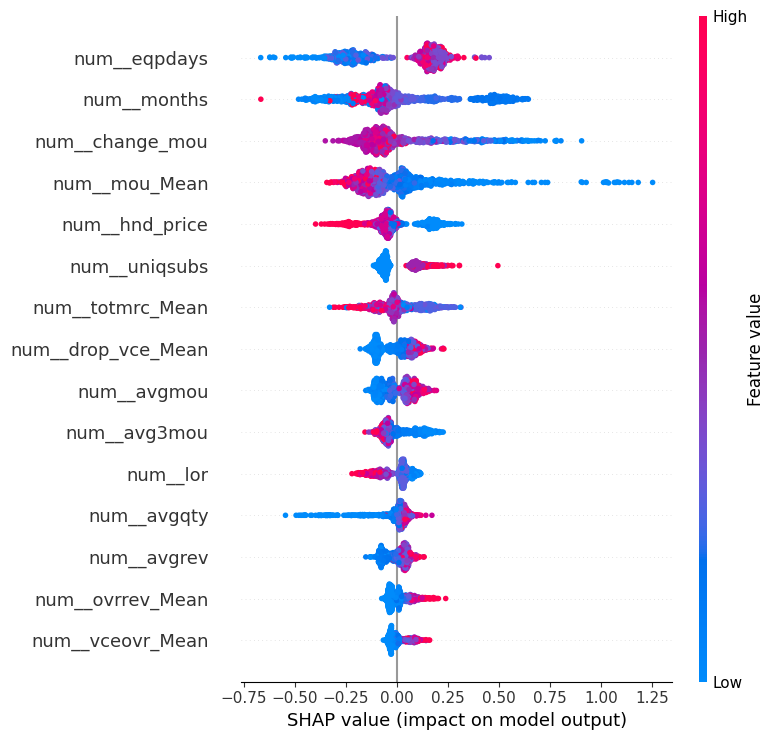

In [87]:
import shap
import matplotlib.pyplot as plt

feature_names = cat_model.named_steps[
    'preprocessor'
].get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names,
    max_display=15
)

In [76]:
highest_rev_idx = df['rev_Mean'].idxmax()

print("Index:", highest_rev_idx)

df.loc[highest_rev_idx, [
    'Customer_ID',
    'rev_Mean',
    'mou_Mean',
    'months',
    'eqpdays',
    'hnd_price',
    'churn'
]]

Index: 39170


,39170
Customer_ID,1039171
rev_Mean,3843.2625
mou_Mean,12206.75
months,16
eqpdays,54.0
hnd_price,149.98999
churn,1


In [88]:
customer = df.loc[[39170]].drop(columns=['churn'])

customer_prob = cat_model.predict_proba(customer)[0,1]

print(f"Churn Probability: {customer_prob:.4f}")

Churn Probability: 0.7162


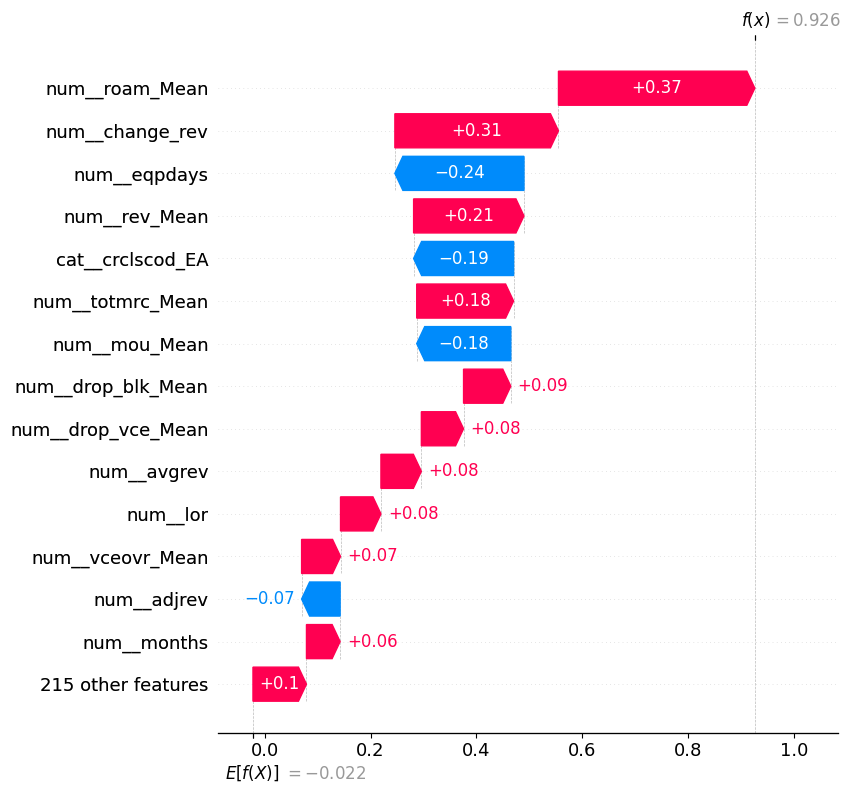

In [89]:
import shap
import numpy as np

customer = df.loc[[39170]].drop(columns=['churn'])

customer_transformed = cat_model.named_steps[
    'preprocessor'
].transform(customer)

customer_shap = explainer.shap_values(customer_transformed)

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    customer_shap[0],
    feature_names=cat_model.named_steps[
        'preprocessor'
    ].get_feature_names_out(),
    max_display=15
)

In [90]:
idx_ovrrev = df['ovrrev_Mean'].idxmax()

print(df.loc[idx_ovrrev, [
    'Customer_ID',
    'ovrrev_Mean',
    'mou_Mean',
    'rev_Mean',
    'churn'
]])

Customer_ID    1002340
ovrrev_Mean     1102.4
mou_Mean        7242.0
rev_Mean       1193.54
churn                1
Name: 2339, dtype: object


In [91]:
idx_roam = df['roam_Mean'].idxmax()

print(df.loc[idx_roam, [
    'Customer_ID',
    'roam_Mean',
    'mou_Mean',
    'rev_Mean',
    'churn'
]])

Customer_ID      1039171
roam_Mean         3685.2
mou_Mean        12206.75
rev_Mean       3843.2625
churn                  1
Name: 39170, dtype: object


In [92]:
idx_vceovr = df['vceovr_Mean'].idxmax()

print(df.loc[idx_vceovr, [
    'Customer_ID',
    'vceovr_Mean',
    'mou_Mean',
    'rev_Mean',
    'churn'
]])

Customer_ID     1046194
vceovr_Mean    896.0875
mou_Mean        3120.25
rev_Mean       926.0775
churn                 0
Name: 46193, dtype: object


In [93]:
idx_datovr = df['datovr_Mean'].idxmax()

print(df.loc[idx_datovr, [
    'Customer_ID',
    'datovr_Mean',
    'mou_Mean',
    'rev_Mean',
    'churn'
]])

Customer_ID    1055551
datovr_Mean     423.54
mou_Mean        1716.0
rev_Mean       499.695
churn                1
Name: 55550, dtype: object


In [94]:
import pandas as pd
import numpy as np

def analyze_customer(idx):

    customer = df.loc[[idx]].drop(columns=['churn'])

    prob = cat_model.predict_proba(customer)[0,1]

    customer_transformed = cat_model.named_steps[
        'preprocessor'
    ].transform(customer)

    shap_values_customer = explainer.shap_values(
        customer_transformed
    )[0]

    feature_names = cat_model.named_steps[
        'preprocessor'
    ].get_feature_names_out()

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap': shap_values_customer
    })

    shap_df['abs_shap'] = abs(shap_df['shap'])

    shap_df = shap_df.sort_values(
        'abs_shap',
        ascending=False
    )

    print("="*60)
    print(f"Index: {idx}")
    print(f"Customer ID: {df.loc[idx,'Customer_ID']}")
    print(f"Actual Churn: {df.loc[idx,'churn']}")
    print(f"Predicted Churn Probability: {prob:.4f}")
    print("="*60)

    display(shap_df.head(10))

    return shap_df

In [95]:
shap_ovr = analyze_customer(2339)

Index: 2339
Customer ID: 1002340
Actual Churn: 1
Predicted Churn Probability: 0.4547


,feature,shap,abs_shap
48,num__months,-0.393455,0.393455
76,num__eqpdays,-0.259457,0.259457
5,num__ovrrev_Mean,0.180388,0.180388
1,num__mou_Mean,-0.153131,0.153131
6,num__vceovr_Mean,0.150023,0.150023
4,num__ovrmou_Mean,0.120798,0.120798
60,num__avg3mou,-0.084907,0.084907
66,num__hnd_price,-0.080448,0.080448
49,num__uniqsubs,-0.077842,0.077842
3,num__da_Mean,0.076072,0.076072


In [96]:
shap_roam = analyze_customer(39170)

Index: 39170
Customer ID: 1039171
Actual Churn: 1
Predicted Churn Probability: 0.7162


,feature,shap,abs_shap
8,num__roam_Mean,0.370870,0.370870
10,num__change_rev,0.308954,0.308954
76,num__eqpdays,-0.243799,0.243799
0,num__rev_Mean,0.208404,0.208404
101,cat__crclscod_EA,-0.188831,0.188831
2,num__totmrc_Mean,0.182956,0.182956
1,num__mou_Mean,-0.177654,0.177654
43,num__drop_blk_Mean,0.089210,0.089210
11,num__drop_vce_Mean,0.079699,0.079699
57,num__avgrev,0.076336,0.076336


In [97]:
shap_voice = analyze_customer(46193)

Index: 46193
Customer ID: 1046194
Actual Churn: 0
Predicted Churn Probability: 0.4271


,feature,shap,abs_shap
10,num__change_rev,0.260386,0.260386
101,cat__crclscod_EA,-0.219958,0.219958
71,num__lor,-0.184075,0.184075
5,num__ovrrev_Mean,0.181089,0.181089
1,num__mou_Mean,-0.163062,0.163062
53,num__totrev,-0.147818,0.147818
4,num__ovrmou_Mean,0.104750,0.104750
6,num__vceovr_Mean,0.094929,0.094929
76,num__eqpdays,0.093230,0.093230
11,num__drop_vce_Mean,-0.089555,0.089555


In [98]:
shap_data = analyze_customer(55550)

Index: 55550
Customer ID: 1055551
Actual Churn: 1
Predicted Churn Probability: 0.4857


,feature,shap,abs_shap
9,num__change_mou,0.428342,0.428342
14,num__blck_dat_Mean,-0.240847,0.240847
1,num__mou_Mean,-0.216244,0.216244
76,num__eqpdays,-0.178926,0.178926
2,num__totmrc_Mean,-0.159340,0.159340
145,cat__area_DC/MARYLAND/VIRGINIA AREA,-0.143765,0.143765
66,num__hnd_price,-0.134463,0.134463
57,num__avgrev,0.125865,0.125865
71,num__lor,0.112255,0.112255
38,num__mou_pead_Mean,0.106668,0.106668


In [99]:
idx_oldest = df['eqpdays'].idxmax()

print(df.loc[idx_oldest, [
    'Customer_ID',
    'eqpdays',
    'months',
    'hnd_price',
    'mou_Mean',
    'rev_Mean',
    'churn'
]])

Customer_ID     1097727
eqpdays          1823.0
months               60
hnd_price      29.98999
mou_Mean          28.75
rev_Mean          6.825
churn                 0
Name: 97726, dtype: object


In [100]:
shap_oldest = analyze_customer(idx_oldest)

Index: 97726
Customer ID: 1097727
Actual Churn: 0
Predicted Churn Probability: 0.1794


,feature,shap,abs_shap
48,num__months,-0.695300,0.695300
2,num__totmrc_Mean,-0.216234,0.216234
66,num__hnd_price,0.206606,0.206606
9,num__change_mou,-0.182000,0.182000
1,num__mou_Mean,0.165763,0.165763
57,num__avgrev,-0.162492,0.162492
56,num__adjqty,-0.152738,0.152738
59,num__avgqty,-0.147100,0.147100
76,num__eqpdays,0.127623,0.127623
60,num__avg3mou,0.110996,0.110996


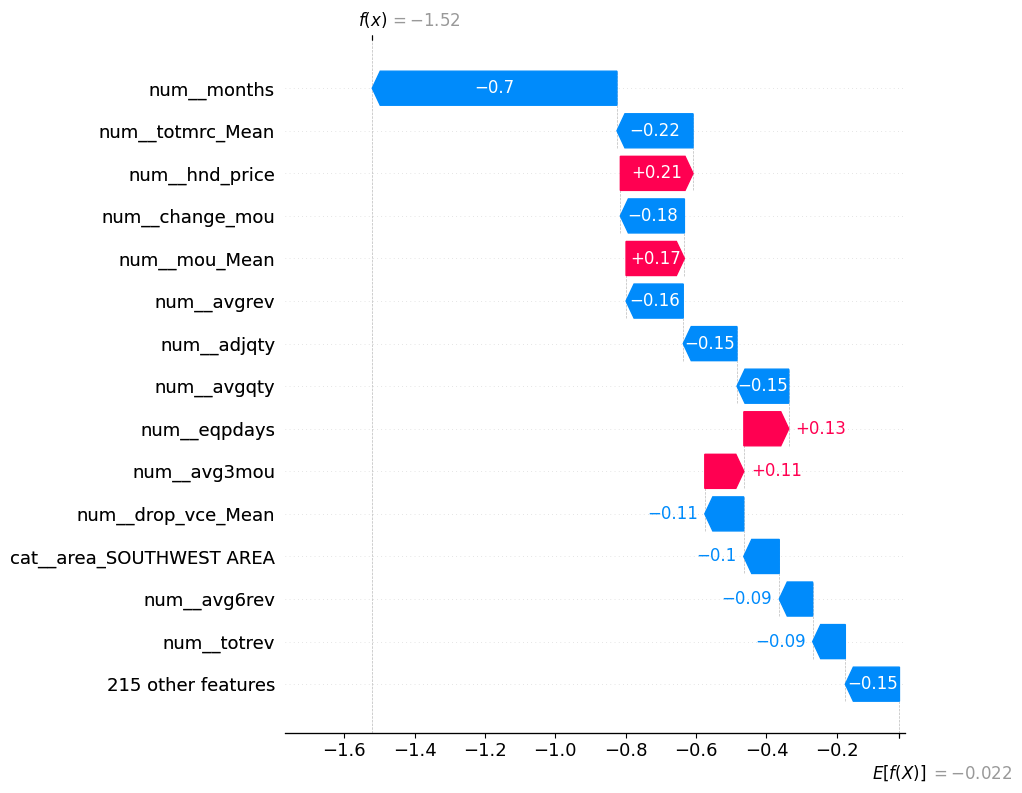

In [101]:
customer = df.loc[[idx_oldest]].drop(columns=['churn'])

customer_transformed = cat_model.named_steps[
    'preprocessor'
].transform(customer)

customer_shap = explainer.shap_values(
    customer_transformed
)

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    customer_shap[0],
    feature_names=cat_model.named_steps[
        'preprocessor'
    ].get_feature_names_out(),
    max_display=15
)

/tmp/ipykernel_3745/3904064924.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('device_age_group')['churn']


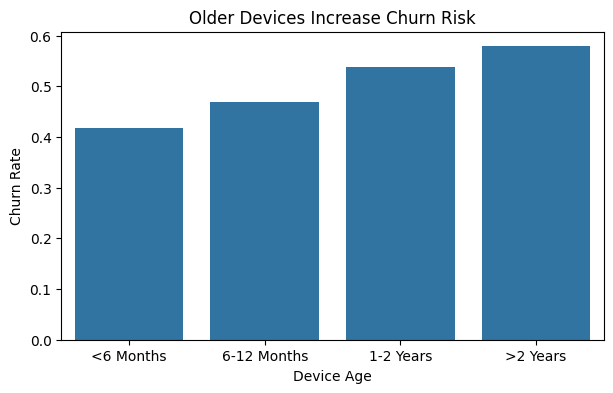

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['device_age_group'] = pd.cut(
    df['eqpdays'],
    bins=[-1,180,365,730,2000],
    labels=['<6 Months','6-12 Months','1-2 Years','>2 Years']
)

churn_device = (
    df.groupby('device_age_group')['churn']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(data=churn_device,
            x='device_age_group',
            y='churn')
plt.ylabel('Churn Rate')
plt.xlabel('Device Age')
plt.title('Older Devices Increase Churn Risk')
plt.show()

/tmp/ipykernel_3745/2973344191.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_change_group')['churn']


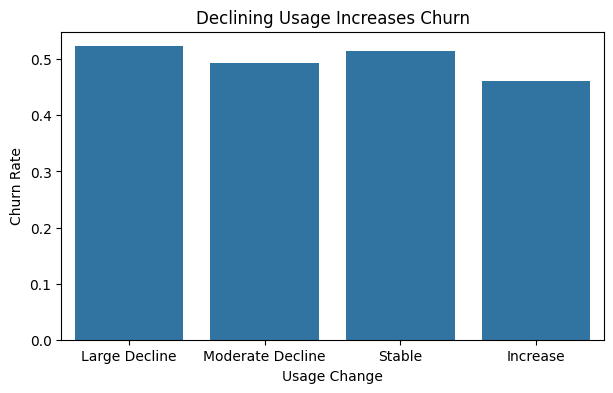

In [52]:
df['usage_change_group'] = pd.cut(
    df['change_mou'],
    bins=[-100000,-50,-10,10,100000],
    labels=['Large Decline','Moderate Decline',
            'Stable','Increase']
)

usage_churn = (
    df.groupby('usage_change_group')['churn']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(data=usage_churn,
            x='usage_change_group',
            y='churn')
plt.ylabel('Churn Rate')
plt.xlabel('Usage Change')
plt.title('Declining Usage Increases Churn')
plt.show()

/tmp/ipykernel_3745/2538310724.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('handset_group')['churn']


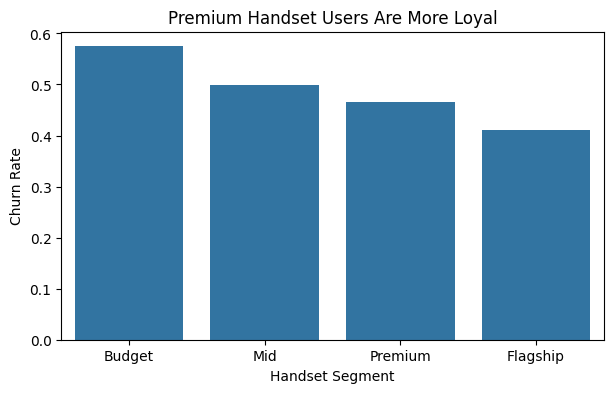

In [53]:
df['handset_group'] = pd.qcut(
    df['hnd_price'],
    q=4,
    labels=['Budget','Mid','Premium','Flagship']
)

price_churn = (
    df.groupby('handset_group')['churn']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(data=price_churn,
            x='handset_group',
            y='churn')
plt.ylabel('Churn Rate')
plt.xlabel('Handset Segment')
plt.title('Premium Handset Users Are More Loyal')
plt.show()

/tmp/ipykernel_3745/4145413334.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ovr_group')['churn']


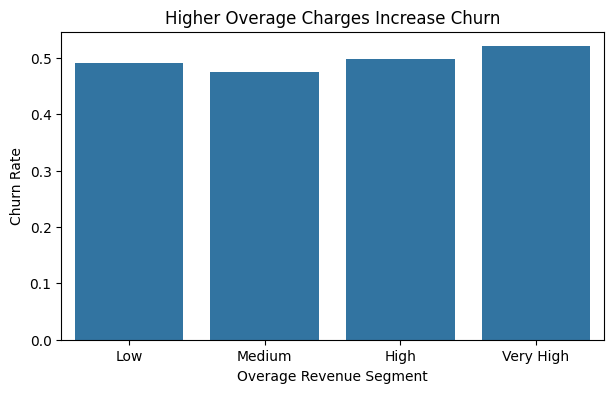

In [56]:
df['ovr_group'] = pd.cut(
    df['ovrrev_Mean'],
    bins=[-0.01, 0.01, 5, 20, df['ovrrev_Mean'].max() + 1],
    labels=['Low','Medium','High','Very High']
)

ovr_churn = (
    df.groupby('ovr_group')['churn']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(data=ovr_churn,
            x='ovr_group',
            y='churn')
plt.ylabel('Churn Rate')
plt.xlabel('Overage Revenue Segment')
plt.title('Higher Overage Charges Increase Churn')
plt.show()

/tmp/ipykernel_3745/260381993.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['churn']


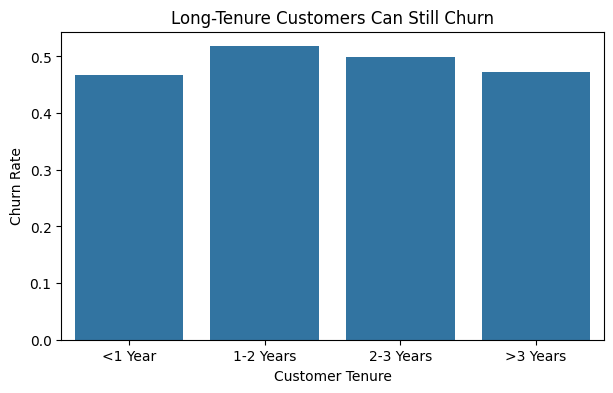

In [57]:
df['tenure_group'] = pd.cut(
    df['months'],
    bins=[0,12,24,36,60],
    labels=['<1 Year',
            '1-2 Years',
            '2-3 Years',
            '>3 Years']
)

tenure_churn = (
    df.groupby('tenure_group')['churn']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(data=tenure_churn,
            x='tenure_group',
            y='churn')
plt.ylabel('Churn Rate')
plt.xlabel('Customer Tenure')
plt.title('Long-Tenure Customers Can Still Churn')
plt.show()